In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import pandas as pd
import numpy as np
import os

os.chdir('../../../results/PlantCAD2_tasks/')

species  = ['arabidopsis_thaliana', 'eutrema_salsugineum', 'oryza_sativa', 'brachypodium_distachyon']
contexts = ['c300', 'c600', 'c1000']
ckpts    = [
    'pcv2-l24-d0768-checkpoints-lr-1e-4',
    'pcv2-l48-d1024-checkpoints-lr-1e-4',
    'pcv2-l48-d1536-checkpoints-lr-1e-4',
    'agront-checkpoints-lr-1e-4',
    'sup_pcv2-l24-d0768-checkpoints-lr-1e-4',
    'cnn-lstm-imbalance-lr-1e-3'
]

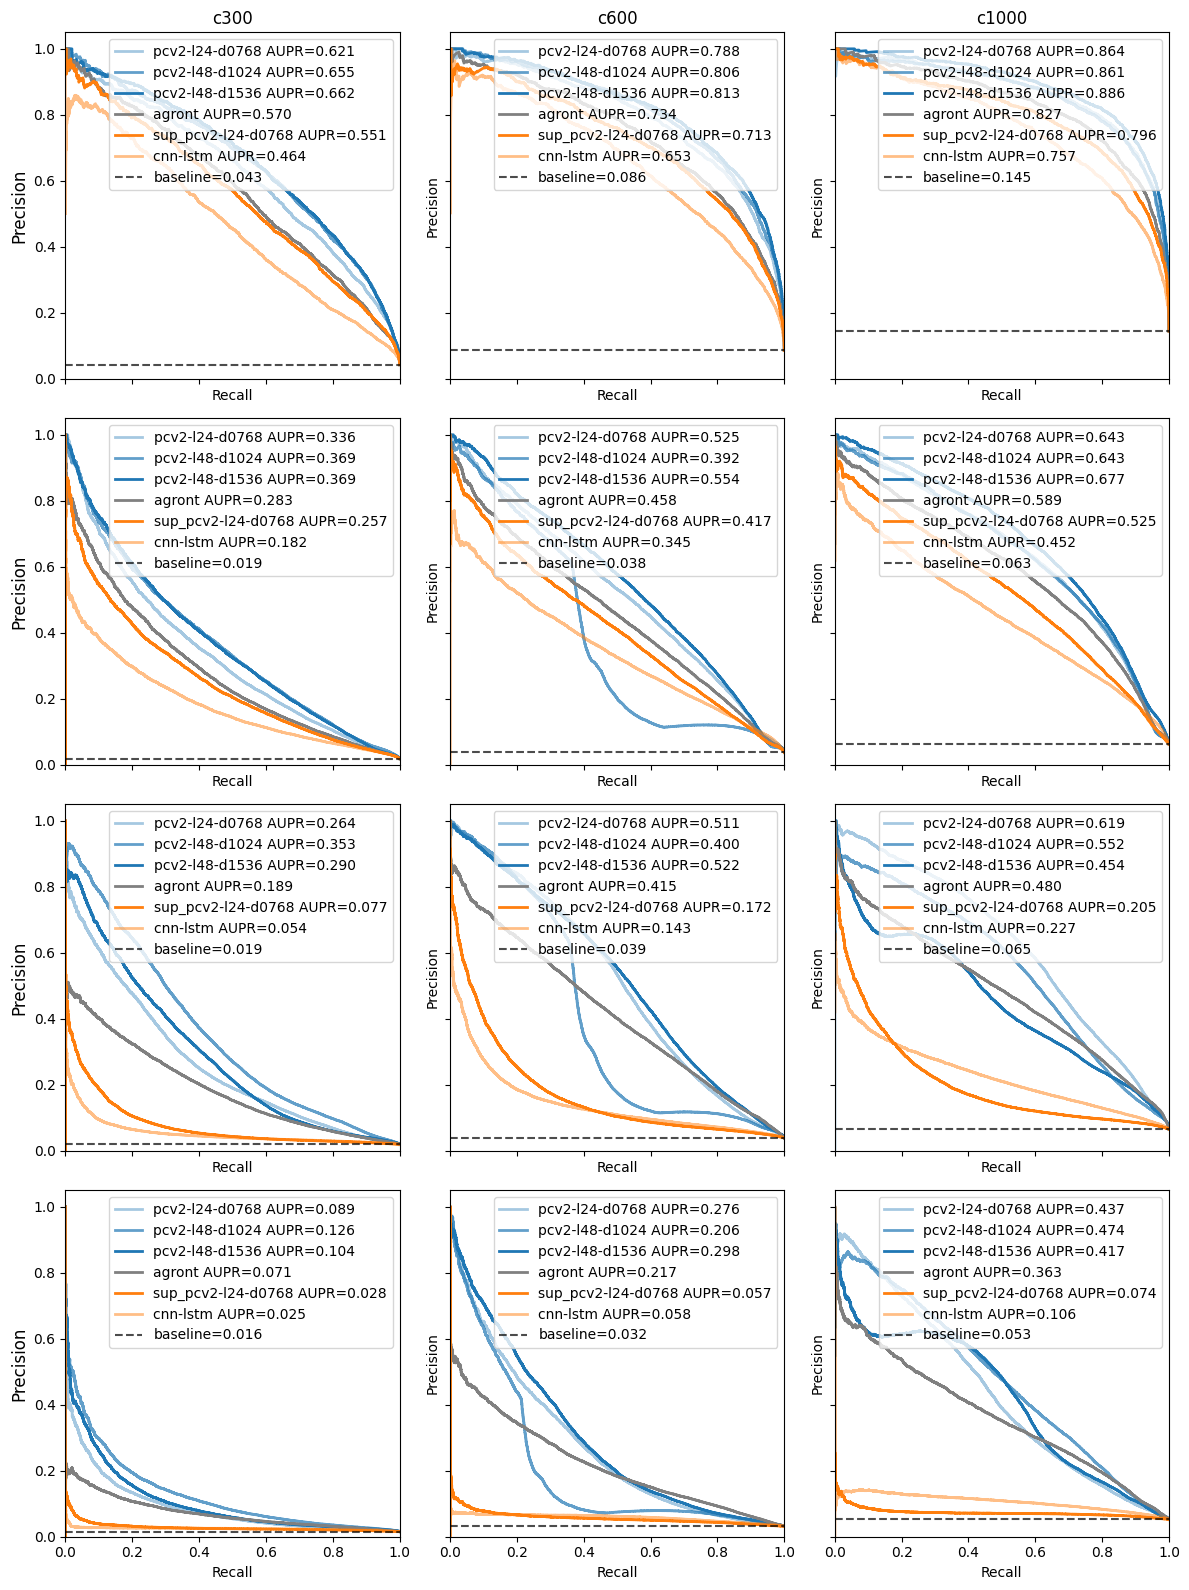

In [2]:
# alpha values for the 3 PCV2 models
pcv2_alphas = [0.4, 0.7, 1.0]

# create a grid of axes: rows = species, cols = contexts
fig, axes = plt.subplots(
    nrows=len(species),
    ncols=len(contexts),
    figsize=(12, 4 * len(species)),
    sharex=True,
    sharey=True
)

for i, sp in enumerate(species):
    for j, ctx in enumerate(contexts):
        ax = axes[i, j]
        ap_scores = {}

        # loop through each checkpoint
        for k, ckpt in enumerate(ckpts):
            if sp == 'arabidopsis_thaliana':
                scores_path = (
                    f'accessible_angiosperm_{ctx}/models/{ckpt}/'
                    f'valid_scores.tsv'
                )
                labels_path = f'accessible_angiosperm_{ctx}/data/valid.tsv'
            else:
                scores_path = (
                    f'accessible_angiosperm_{ctx}/models/{ckpt}/'
                    f'test_{sp}_scores.tsv'
                )
                labels_path = f'accessible_angiosperm_{ctx}/data/test_{sp}.tsv'

            # load
            preds = pd.read_csv(scores_path, sep='\t')
            labs  = pd.read_csv(labels_path, sep='\t')

            y_scores = preds['probability_positive']
            y_true   = labs['Label']

            # compute PR & AP
            precision, recall, _ = precision_recall_curve(y_true, y_scores)
            ap = average_precision_score(y_true, y_scores)
            ap_scores[ckpt] = ap

            # pick color+alpha
            if 'agront' in ckpt.lower():
                color, alpha = 'gray', 1.0
            elif 'sup_pcv2' in ckpt.lower():
                color, alpha = 'C1', 1.0
            elif 'cnn' in ckpt.lower():
                color, alpha = 'C1', 0.5
            else:
                color = 'C0'
                alpha = pcv2_alphas[k]  # 0.4, 0.7, 1.0

            if 'cnn' in ckpt.lower():
                model_prefix = ckpt.replace('-imbalance-lr-1e-3', '')
            elif 'sup_pcv2' in ckpt.lower():
                model_prefix = ckpt.replace('-checkpoints-lr-1e-4', '')
            else:
                model_prefix = ckpt.replace('-checkpoints-lr-1e-4', '')
            # plot PR curve
            ax.plot(
                recall, precision,
                lw=2,
                color=color,
                alpha=alpha,
                label=f"{model_prefix} AUPR={ap:.3f}"
        )

        # baseline prevalence
        baseline = np.mean(y_true)
        ax.hlines(
            baseline, 0, 1,
            linestyle='--',
            linewidth=1.5,
            color='black',
            alpha=0.7,
            label=f'baseline={baseline:.3f}'
        )

        # only label the top row with context titles
        if i == 0:
            ax.set_title(ctx, fontsize=12)

        # only label the left column with species names
        if j == 0:
            ax.set_ylabel(sp, fontsize=12)

        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(loc='upper right')

# tighten and show
plt.tight_layout()
plt.savefig('../../pipelines/lu_2019_ATACseq/figures/pr_curves_all_species.pdf', format='pdf', bbox_inches='tight')
plt.show()